# はじめに

このノートでは、PyTorch Geometricを利用してグラフニューラルネットワークを構築することを目指す。最初はPyTorchの基礎からはじめ、グラフニューラルネットワーク、PyTorch Geometricと内容を進めていく。

前回は、PyTorch Geometricを使って競艇の「展開」を捉えるための埋め込みを可視化する際によく利用されているt-SNEへの理解を深める。t-SNE以外にもPCAやUMAPなどもあるが、ここではt-SNEを対象とする。

下記はグラフニューラルネットワークを理解するための参考サイト。

- [グラフニューラルネットワーク | 佐藤 竜馬](https://www.amazon.co.jp/%E3%82%B0%E3%83%A9%E3%83%95%E3%83%8B%E3%83%A5%E3%83%BC%E3%83%A9%E3%83%AB%E3%83%8D%E3%83%83%E3%83%88%E3%83%AF%E3%83%BC%E3%82%AF-%E6%A9%9F%E6%A2%B0%E5%AD%A6%E7%BF%92%E3%83%97%E3%83%AD%E3%83%95%E3%82%A7%E3%83%83%E3%82%B7%E3%83%A7%E3%83%8A%E3%83%AB%E3%82%B7%E3%83%AA%E3%83%BC%E3%82%BA-%E4%BD%90%E8%97%A4-%E7%AB%9C%E9%A6%AC/dp/4065347823)
- [グラフ深層学習のすゝめ。 - YouTube](https://www.youtube.com/watch?v=7rgXi3Xp6NI)
- [GCN — グラフ道場](https://yuya-s.github.io/GraphDojo/01GCN.html)
- [Tutorial 6: Basics of Graph Neural Networks](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html)
- [Static and Dynamic Attention: Implications for Graph Neural Networks](https://medium.com/data-science/static-and-dynamic-attention-implications-for-graph-neural-networks-eda0d9d7b60a)
- [CS224W | Home](https://web.stanford.edu/class/cs224w/index.html)
- [nn.labml.ai/ja/graphs](https://nn.labml.ai/#:~:text=%E2%9C%A8%20Graph%20Neural%20Networks)
- [Understanding Convolutions on Graphs](https://distill.pub/2021/understanding-gnns/)
- [A Gentle Introduction to Graph Neural Networks](https://distill.pub/2021/gnn-intro/)

## t-SNEとは

t-SNE(t-distributed Stochastic Neighbor Embedding)は、高次元データを次元圧縮し、クラスター構造を可視化する非線形次元削減手法。特徴としては、似ているデータ点同士を近くに配置し、異なる点同士が遠くなるよう配置する特徴がある。つまり、名前の由来の通り、t分布を使って確率的に近いデータを低次元に埋め込む手法である。解説記事はたくさん探せば出てくるので、これ以上は触れない。論文は下記の通り。

- [Hinton, Geoffrey; Roweis, Sam (January 2002). Stochastic neighbor embedding. Neural Information Processing Systems.](https://www.cs.toronto.edu/~fritz/absps/sne.pdf)

下記の動画はイメージを掴みやすい。

- [t-SNE - Explained - YouTube](https://www.youtube.com/watch?v=b-AvYLqLWd0)
- [t-SNE - simple explanation with an example! - YouTube](https://www.youtube.com/watch?v=SDXbNOB590Q)

## t-SNEの数理

Latexを書くのがめんどくさいので、手書きでメモを貼り付けておく。小数点については「およそ」で、注意散漫な結果$=,\approx$が混在しているので注意。あくまでも計算内容のイメージを使うためのメモ。

<div align='center'><img src='./tsne1.png' width='1200'></div>
<div align='center'><img src='./tsne2.png' width='1200'></div>
<div align='center'><img src='./tsne3.png' width='1200'></div>
<div align='center'><img src='./tsne4.png' width='1200'></div>
<div align='center'><img src='./tsne5.png' width='1200'></div>
<div align='center'><img src='./tsne6.png' width='1200'></div>
<div align='center'><img src='./tsne7.png' width='1200'></div>
<div align='center'><img src='./tsne8.png' width='1200'></div>
<div align='center'><img src='./tsne9.png' width='1200'></div>
<div align='center'><img src='./tsne10.png' width='1200'></div>


## 可視化

下記に記載されていたコードを参考にしている。一部修正している。

- [t-SNE from Scratch (ft. NumPy)](https://medium.com/data-science/t-sne-from-scratch-ft-numpy-172ee2a61df7)

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Fetch MNIST data
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
mnist.target = mnist.target.astype(np.uint8)

X_total = pd.DataFrame(mnist["data"])
y_total = pd.DataFrame(mnist["target"])

X_reduced = X_total.sample(n=1000)
y_reduced = y_total.loc[X_reduced.index]

# PCA to keep 30 components
X = PCA(n_components=30).fit_transform(X_reduced)
X.shape

(1000, 30)

In [ ]:
def get_original_pairwise_affinities(X: np.ndarray, perplexity: int = 10) -> np.ndarray:
    """
    アフィニティ行列を計算する関数。

    引数:
    X (np.ndarray): 入力データ配列。
    perplexity (int): グリッドサーチで使用するperplexityの値。

    戻り値:
    np.ndarray: ペアワイズアフィニティ行列。
    """

    n = len(X)

    print("Computing Pairwise Affinities....")

    p_ij = np.zeros(shape=(n, n))
    for i in range(0, n):
        # Equation 1 numerator
        diff = X[i] - X
        sigma_i = grid_search(diff, i, perplexity)  # Grid Search for sigma_i
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = np.exp(-(norm**2) / (2 * sigma_i**2))

        # Set p = 0 when j = i
        np.fill_diagonal(p_ij, 0)

        # Equation 1
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])

    # Set 0 values to minimum numpy value (ε approx. = 0)
    ε = np.nextafter(0, 1)
    p_ij = np.maximum(p_ij, ε)

    print("Completed Pairwise Affinities Matrix. \n")

    return p_ij


def grid_search(diff_i: np.ndarray, i: int, perplexity: int) -> float:
    """
    ユーザー指定のperplexityに基づいてsigmaを求める補助関数。

    引数:
        diff_i (np.ndarray): データ点間の差分を格納した配列。
        i (int): 現在のデータ点のインデックス。
        perplexity (int): ユーザー指定のperplexity値。

    戻り値:
        float: perplexity条件を満たすsigmaの値。
    """

    result = np.inf  # Set first result to be infinity

    ε = np.nextafter(0, 1)
    norm = np.linalg.norm(diff_i, axis=1)
    # Avoid zero-width search range when all distances are identical.
    std_norm = max(np.std(norm), ε)
    sigma = std_norm  # Fallback if all candidates are skipped

    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        # Equation 1 Numerator
        p = np.exp(-(norm**2) / (2 * sigma_search**2))

        # Set p = 0 when i = j
        p[i] = 0

        # Equation 1 (ε -> 0)
        denominator = np.sum(p)
        if denominator <= ε or not np.isfinite(denominator):
            continue
        p_new = np.maximum(p / denominator, ε)

        # Shannon Entropy
        H = -np.sum(p_new * np.log2(p_new))

        # Get log(perplexity equation) as close to equality
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search

    return sigma


def get_symmetric_p_ij(p_ij: np.ndarray) -> np.ndarray:
    """
    t-SNEで使用する対称アフィニティ行列を計算する関数。

    引数:
    p_ij (np.ndarray): 入力アフィニティ行列。

    戻り値:
    np.ndarray: 対称化されたアフィニティ行列。

    """
    print("Computing Symmetric p_ij matrix....")

    n = len(p_ij)
    p_ij_symmetric = np.zeros(shape=(n, n))
    for i in range(0, n):
        for j in range(0, n):
            p_ij_symmetric[i, j] = (p_ij[i, j] + p_ij[j, i]) / (2 * n)

    # Set 0 values to minimum numpy value (ε approx. = 0)
    ε = np.nextafter(0, 1)
    p_ij_symmetric = np.maximum(p_ij_symmetric, ε)

    print("Completed Symmetric p_ij Matrix. \n")

    return p_ij_symmetric


def initialization(
    X: np.ndarray, n_dimensions: int = 2, initialization: str = "random"
) -> np.ndarray:
    """
    t-SNEの初期解をランダムまたはPCAで生成する。

    引数:
        X (np.ndarray): 入力データ配列。
        n_dimensions (int): 出力解の次元数。既定値は2。
        initialization (str): 初期化方法。'random' または 'PCA' を指定。既定値は 'random'。

    戻り値:
        np.ndarray: t-SNEの初期解。

    例外:
        ValueError: 初期化方法が 'random' または 'PCA' でない場合。
    """

    # Sample Initial Solution
    if initialization == "random":
        y0 = np.random.normal(loc=0, scale=1e-4, size=(len(X), n_dimensions))
    elif initialization == "PCA":
        X_centered = X - X.mean(axis=0)
        _, _, Vt = np.linalg.svd(X_centered)
        y0 = X_centered @ Vt.T[:, :n_dimensions]
    else:
        raise ValueError("Initialization must be 'random' or 'PCA'")

    return y0


def get_low_dimensional_affinities(Y: np.ndarray) -> np.ndarray:
    """
    低次元空間でのアフィニティを計算する。

    引数:
    Y (np.ndarray): データ点の低次元表現。

    戻り値:
    np.ndarray: 低次元アフィニティ行列。
    """

    n = len(Y)
    q_ij = np.zeros(shape=(n, n))

    for i in range(0, n):
        # Equation 4 Numerator
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1)

    # Set p = 0 when j = i
    np.fill_diagonal(q_ij, 0)

    # Equation 4
    q_ij = q_ij / q_ij.sum()

    # Set 0 values to minimum numpy value (ε approx. = 0)
    ε = np.nextafter(0, 1)
    q_ij = np.maximum(q_ij, ε)

    return q_ij


def get_gradient(p_ij: np.ndarray, q_ij: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """
    現在の点Yにおけるコスト関数の勾配を計算する。

    引数:
    p_ij (np.ndarray): 同時確率分布行列。
    q_ij (np.ndarray): Studentのt分布行列。
    Y (np.ndarray): 低次元空間における現在の点。

    戻り値:
    np.ndarray: 現在の点Yにおけるコスト関数の勾配。
    """

    n = len(p_ij)

    # Compute gradient
    gradient = np.zeros(shape=(n, Y.shape[1]))
    for i in range(0, n):
        # Equation 5
        diff = Y[i] - Y
        A = np.array([p_ij[i, :] - q_ij[i, :]])
        B = np.array([(1 + np.linalg.norm(diff, axis=1) ** 2) ** (-1)])
        C = diff
        gradient[i] = 4 * np.sum((A * B).T * C, axis=0)

    return gradient


def tsne(
    X: np.ndarray,
    perplexity: int = 10,
    T: int = 1000,
    η: int = 200,
    early_exaggeration: int = 4,
    n_dimensions: int = 2,
) -> list[np.ndarray, np.ndarray]:
    """
    t-SNE（t-Distributed Stochastic Neighbor Embedding）アルゴリズムの実装。

    引数:
        X (np.ndarray): 形状 (n_samples, n_features) の入力データ行列。
        perplexity (int, optional): perplexityパラメータ。既定値は10。
        T (int, optional): 最適化の反復回数。既定値は1000。
        η (int, optional): 低次元埋め込みを更新する学習率。既定値は200。
        early_exaggeration (int, optional): 最適化初期の反復において
            ペアワイズアフィニティを強調する係数。既定値は4。
        n_dimensions (int, optional): 低次元埋め込みの次元数。既定値は2。

    戻り値:
        list[np.ndarray, np.ndarray]: 最終的な低次元埋め込みと、
            各反復における埋め込み履歴を含むリスト。

    """
    n = len(X)

    # Get original affinities matrix
    p_ij = get_original_pairwise_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    # Initialization
    Y = np.zeros(shape=(T, n, n_dimensions))
    Y_minus1 = np.zeros(shape=(n, n_dimensions))
    Y[0] = Y_minus1
    Y1 = initialization(X, n_dimensions)
    Y[1] = np.array(Y1)

    print("Optimizing Low Dimensional Embedding....")
    # Optimization
    for t in range(1, T - 1):
        # Momentum & Early Exaggeration
        if t < 250:
            α = 0.5
            early_exaggeration = early_exaggeration
        else:
            α = 0.8
            early_exaggeration = 1

        # Get Low Dimensional Affinities
        q_ij = get_low_dimensional_affinities(Y[t])

        # Get Gradient of Cost Function
        gradient = get_gradient(early_exaggeration * p_ij_symmetric, q_ij, Y[t])

        # Update Rule
        Y[t + 1] = Y[t] - η * gradient + α * (Y[t] - Y[t - 1])  # Use negative gradient

        # Compute current value of cost function
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Value of Cost Function is {cost}")

    print(
        f"Completed Low Dimensional Embedding: Final Value of Cost Function is {np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))}"
    )
    solution = Y[-1]

    return solution, Y

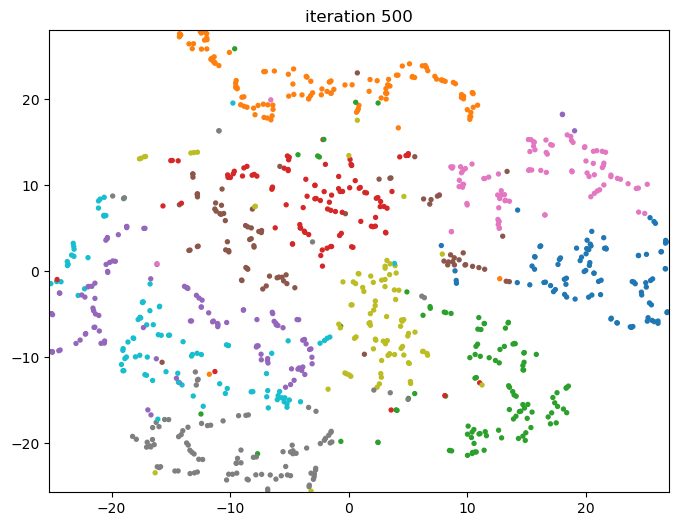

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


# t-SNE 実行
Y_final, Y_history = tsne(X, perplexity=10, T=500)

# 2次元座標
x = Y_final[:, 0]
y = Y_final[:, 1]

# Y_history全体でのx/yスケール範囲の算出
all_x = np.concatenate([Y_history[t][:, 0] for t in range(Y_history.shape[0])])
all_y = np.concatenate([Y_history[t][:, 1] for t in range(Y_history.shape[0])])
x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

fig, ax = plt.subplots(figsize=(8, 6))

# Y_history.shape[0] 回数分だけループ
step = 5
for t in range(0, Y_history.shape[0], step):
    clear_output(wait=True)  # Jupyter用: 前出力を消す
    ax.clear()
    ax.scatter(
        Y_history[t][:, 0],
        Y_history[t][:, 1],
        c=y_reduced.values.flatten(),
        cmap="tab10",
        s=8,
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    # 最後のイテレーションかどうか判定
    if t == Y_history.shape[0] - 1:
        ax.set_title(f"iteration {t+step} (final)")
    else:
        ax.set_title(f"iteration {t+step}")
    display(fig)

plt.close(fig)